In [ ]:
!pip install -q scikit-learn pandas numpy joblib

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Number of records
n = 5000

# Create input features
data = pd.DataFrame({

    "account_age_days": np.random.uniform(10, 75, n),

    "linked_accounts": np.random.uniform(0, 20, n),

    "mentions": np.random.uniform(0, 6, n),

    "months_active": np.random.uniform(0, 40, n),

    "post_length": np.random.uniform(0, 100, n),

    "reach": np.random.uniform(0, 100, n),

    "recent_strikes": np.random.uniform(0, 5, n),

    "report_ratio": np.random.uniform(0, 1, n),

    "reputation": np.random.uniform(100, 900, n),

    "surface": np.random.choice(
        ["A", "B", "C", "D"],
        n
    )
})

# Convert surface into a number for the ML model
surface_map = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3
}

data["surface_code"] = data["surface"].map(surface_map)

# Create the hidden relationship for our black box
score = (

    0.20 * (data["account_age_days"] / 75)

    + 0.08 * (data["linked_accounts"] / 20)

    + 0.05 * (data["mentions"] / 6)

    + 0.10 * (data["months_active"] / 40)

    + 0.05 * (1 - data["post_length"] / 100)

    + 0.05 * (1 - data["reach"] / 100)

    + 0.20 * (1 - data["recent_strikes"] / 5)

    + 0.12 * (1 - data["report_ratio"])

    + 0.20 * (data["reputation"] / 900)
)

# Add a little randomness
noise = np.random.normal(0, 0.04, n)

data["score"] = np.clip(
    score + noise,
    0,
    1
)

# Create decision
data["decision"] = np.where(
    data["score"] >= 0.50,
    "APPROVE",
    "DECLINE"
)

print("Dataset created successfully!")
print("Number of rows:", len(data))

data.head(10)

Dataset created successfully!
Number of rows: 5000


,account_age_days,linked_accounts,mentions,months_active,post_length,reach,recent_strikes,report_ratio,reputation,surface,surface_code,score,decision
0,34.345108,7.872710,2.241845,19.986810,72.999831,9.237084,3.190723,0.609393,339.129633,B,1,0.449822,DECLINE
1,71.796430,9.468713,1.997473,29.869871,18.451200,6.075373,2.296462,0.038903,175.854220,B,1,0.647997,APPROVE
2,57.579606,17.090948,1.056923,22.506671,34.663969,60.419195,4.822493,0.612260,201.087380,C,2,0.480971,DECLINE
3,48.912801,6.800088,3.643600,3.332103,66.328064,96.611632,1.094892,0.089669,244.536903,D,3,0.595658,APPROVE
4,20.141212,17.392994,2.859745,7.423209,48.208934,50.272131,2.939282,0.710344,262.922667,B,1,0.340509,DECLINE
5,20.139644,1.762689,5.194206,8.773127,73.857104,5.151523,3.501050,0.390078,293.809447,A,0,0.391480,DECLINE
6,13.775435,15.535969,0.192657,10.314570,96.120790,22.121866,4.127822,0.837696,304.368023,B,1,0.270424,DECLINE
7,66.301449,16.950953,3.863208,22.616136,11.654669,24.479291,2.034855,0.942529,464.573076,D,3,0.681039,APPROVE
8,49.072476,3.636353,4.577693,20.158631,70.956772,33.785713,3.434610,0.417110,507.658553,B,1,0.526450,APPROVE
9,56.024718,8.606931,4.556919,8.126402,23.034416,4.360338,1.516007,0.460555,347.103367,A,0,0.611774,APPROVE


In [ ]:
data.to_csv(
    "blackbox_round4_dataset.csv",
    index=False
)

print("CSV file created successfully!")

CSV file created successfully!


In [ ]:
print("Dataset shape:")
print(data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nDecision distribution:")
print(data["decision"].value_counts())

Dataset shape:
(5000, 13)

Columns:
['account_age_days', 'linked_accounts', 'mentions', 'months_active', 'post_length', 'reach', 'recent_strikes', 'report_ratio', 'reputation', 'surface', 'surface_code', 'score', 'decision']

Missing values:
account_age_days    0
linked_accounts     0
mentions            0
months_active       0
post_length         0
reach               0
recent_strikes      0
report_ratio        0
reputation          0
surface             0
surface_code        0
score               0
decision            0
dtype: int64

Decision distribution:
decision
APPROVE    3307
DECLINE    1693
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "account_age_days",
    "linked_accounts",
    "mentions",
    "months_active",
    "post_length",
    "reach",
    "recent_strikes",
    "report_ratio",
    "reputation",
    "surface_code"
]

X = data[features]
y = data["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ ML model trained successfully!")

✅ ML model trained successfully!


In [ ]:
predictions = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error:", round(mae, 4))
print("R2 Score:", round(r2, 4))

Mean Absolute Error: 0.0389
R2 Score: 0.8311


In [ ]:
def blackbox_query(
    account_age_days,
    linked_accounts,
    mentions,
    months_active,
    post_length,
    reach,
    recent_strikes,
    report_ratio,
    reputation,
    surface
):

    surface_code = {
        "A": 0,
        "B": 1,
        "C": 2,
        "D": 3
    }[surface]

    input_data = pd.DataFrame([{
        "account_age_days": account_age_days,
        "linked_accounts": linked_accounts,
        "mentions": mentions,
        "months_active": months_active,
        "post_length": post_length,
        "reach": reach,
        "recent_strikes": recent_strikes,
        "report_ratio": report_ratio,
        "reputation": reputation,
        "surface_code": surface_code
    }])

    predicted_score = float(
        model.predict(input_data)[0]
    )

    predicted_score = max(
        0,
        min(1, predicted_score)
    )

    decision = (
        "APPROVE"
        if predicted_score >= 0.50
        else "DECLINE"
    )

    return predicted_score, decision

In [ ]:
score, decision = blackbox_query(
    account_age_days=75,
    linked_accounts=10,
    mentions=3,
    months_active=20,
    post_length=50,
    reach=50,
    recent_strikes=0,
    report_ratio=0.5,
    reputation=600,
    surface="A"
)

print("BLACK BOX RESULT")
print("----------------")
print("Score:", round(score, 4))
print("Decision:", decision)

BLACK BOX RESULT
----------------
Score: 0.7217
Decision: APPROVE


In [ ]:
for reputation in [100, 200, 300, 400, 500, 600, 700, 800, 900]:

    score, decision = blackbox_query(
        account_age_days=50,
        linked_accounts=10,
        mentions=3,
        months_active=20,
        post_length=50,
        reach=50,
        recent_strikes=1,
        report_ratio=0.2,
        reputation=reputation,
        surface="A"
    )

    print(
        "Reputation:",
        reputation,
        "Score:",
        round(score, 4),
        "Decision:",
        decision
    )

Reputation: 100 Score: 0.595 Decision: APPROVE
Reputation: 200 Score: 0.6084 Decision: APPROVE
Reputation: 300 Score: 0.6265 Decision: APPROVE
Reputation: 400 Score: 0.6464 Decision: APPROVE
Reputation: 500 Score: 0.6899 Decision: APPROVE
Reputation: 600 Score: 0.7147 Decision: APPROVE
Reputation: 700 Score: 0.7289 Decision: APPROVE
Reputation: 800 Score: 0.7458 Decision: APPROVE
Reputation: 900 Score: 0.7489 Decision: APPROVE


In [ ]:
for strikes in [0, 1, 2, 3, 4, 5]:

    score, decision = blackbox_query(
        account_age_days=50,
        linked_accounts=10,
        mentions=3,
        months_active=20,
        post_length=50,
        reach=50,
        recent_strikes=strikes,
        report_ratio=0.2,
        reputation=600,
        surface="A"
    )

    print(
        "Recent strikes:",
        strikes,
        "Score:",
        round(score, 4),
        "Decision:",
        decision
    )

Recent strikes: 0 Score: 0.7346 Decision: APPROVE
Recent strikes: 1 Score: 0.7147 Decision: APPROVE
Recent strikes: 2 Score: 0.6882 Decision: APPROVE
Recent strikes: 3 Score: 0.6007 Decision: APPROVE
Recent strikes: 4 Score: 0.584 Decision: APPROVE
Recent strikes: 5 Score: 0.5663 Decision: APPROVE


In [ ]:
import joblib

joblib.dump(
    model,
    "blackbox_round4_model.pkl"
)

print("✅ Model saved!")

✅ Model saved!


In [ ]:
import joblib
import pandas as pd

# Load the trained model
model = joblib.load("blackbox_round4_model.pkl")

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [ ]:
test_input = pd.DataFrame([{
    "account_age_days": 50,
    "linked_accounts": 10,
    "mentions": 3,
    "months_active": 20,
    "post_length": 50,
    "reach": 50,
    "recent_strikes": 1,
    "report_ratio": 0.5,
    "reputation": 500,
    "surface_code": 1
}])

test_input

,account_age_days,linked_accounts,mentions,months_active,post_length,reach,recent_strikes,report_ratio,reputation,surface_code
0,50,10,3,20,50,50,1,0.5,500,1


In [ ]:
prediction = model.predict(test_input)

score = float(prediction[0])

if score >= 0.5:
    decision = "APPROVE"
else:
    decision = "DECLINE"

print("================================")
print("     BLACKBOX AI — ROUND 4")
print("================================")
print()
print("Input:")
print(test_input.to_string(index=False))
print()
print(f"Predicted Score : {score:.4f}")
print(f"Decision        : {decision}")
print("================================")

     BLACKBOX AI — ROUND 4

Input:
 account_age_days  linked_accounts  mentions  months_active  post_length  reach  recent_strikes  report_ratio  reputation  surface_code
               50               10         3             20           50     50               1           0.5         500             1

Predicted Score : 0.6445
Decision        : APPROVE


In [ ]:
test_cases = pd.DataFrame([
    {
        "account_age_days": 20,
        "linked_accounts": 5,
        "mentions": 1,
        "months_active": 5,
        "post_length": 20,
        "reach": 20,
        "recent_strikes": 3,
        "report_ratio": 0.8,
        "reputation": 200,
        "surface_code": 0
    },
    {
        "account_age_days": 50,
        "linked_accounts": 10,
        "mentions": 3,
        "months_active": 20,
        "post_length": 50,
        "reach": 50,
        "recent_strikes": 1,
        "report_ratio": 0.5,
        "reputation": 500,
        "surface_code": 1
    },
    {
        "account_age_days": 70,
        "linked_accounts": 15,
        "mentions": 2,
        "months_active": 35,
        "post_length": 70,
        "reach": 70,
        "recent_strikes": 0,
        "report_ratio": 0.1,
        "reputation": 800,
        "surface_code": 3
    }
])

scores = model.predict(test_cases)

results = test_cases.copy()
results["score"] = scores
results["decision"] = results["score"].apply(
    lambda x: "APPROVE" if x >= 0.5 else "DECLINE"
)

results

,account_age_days,linked_accounts,mentions,months_active,post_length,reach,recent_strikes,report_ratio,reputation,surface_code,score,decision
0,20,5,1,5,20,20,3,0.8,200,0,0.339195,DECLINE
1,50,10,3,20,50,50,1,0.5,500,1,0.644471,APPROVE
2,70,15,2,35,70,70,0,0.1,800,3,0.797069,APPROVE


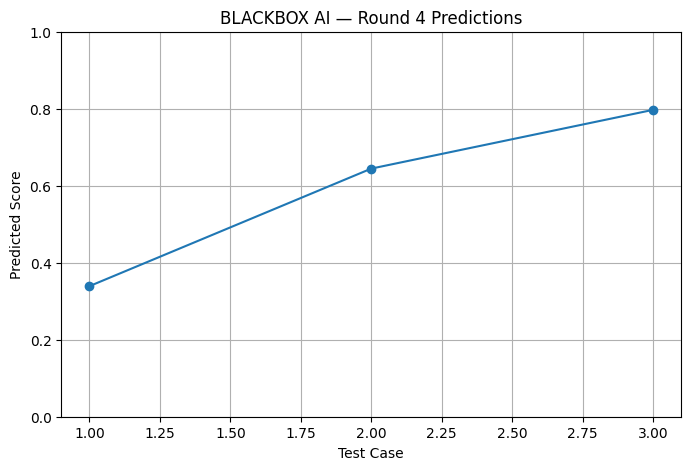

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(results) + 1),
    results["score"],
    marker="o"
)

plt.xlabel("Test Case")
plt.ylabel("Predicted Score")
plt.title("BLACKBOX AI — Round 4 Predictions")
plt.ylim(0, 1)
plt.grid(True)

plt.show()

In [ ]:
test_input = pd.DataFrame([{
    "account_age_days": 60,
    "linked_accounts": 12,
    "mentions": 2,
    "months_active": 25,
    "post_length": 40,
    "reach": 40,
    "recent_strikes": 0,
    "report_ratio": 0.2,
    "reputation": 700,
    "surface_code": 2
}])

score = float(model.predict(test_input)[0])

decision = "APPROVE" if score >= 0.5 else "DECLINE"

print("BLACKBOX AI — ROUND 4")
print("----------------------")
print(f"Predicted Score : {score:.4f}")
print(f"Decision        : {decision}")

BLACKBOX AI — ROUND 4
----------------------
Predicted Score : 0.7710
Decision        : APPROVE


In [ ]:
# ==========================================
# BLACKBOX AI — ROUND 4 FINAL TEST
# ==========================================

final_input = pd.DataFrame([{
    "account_age_days": 50,
    "linked_accounts": 10,
    "mentions": 3,
    "months_active": 20,
    "post_length": 50,
    "reach": 50,
    "recent_strikes": 1,
    "report_ratio": 0.5,
    "reputation": 500,
    "surface_code": 1
}])

# Predict score
final_score = float(model.predict(final_input)[0])

# Decision
if final_score >= 0.5:
    final_decision = "APPROVE"
else:
    final_decision = "DECLINE"

print("=" * 45)
print("       BLACKBOX AI — ROUND 4")
print("=" * 45)

print("\nINPUT VALUES")
print(final_input.to_string(index=False))

print("\nRESULT")
print(f"Score    : {final_score:.4f}")
print(f"Decision : {final_decision}")

print("=" * 45)

       BLACKBOX AI — ROUND 4

INPUT VALUES
 account_age_days  linked_accounts  mentions  months_active  post_length  reach  recent_strikes  report_ratio  reputation  surface_code
               50               10         3             20           50     50               1           0.5         500             1

RESULT
Score    : 0.6445
Decision : APPROVE


In [ ]:
results.to_csv("blackbox_round4_results.csv", index=False)

print("✅ Results saved as blackbox_round4_results.csv")

✅ Results saved as blackbox_round4_results.csv
